In [2]:
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime, timezone, timedelta
from functools import lru_cache
from numpy import radians, sin, cos, arctan2, degrees
from pyproj import Transformer
from skyfield.api import load, Topos
from skyfield.almanac import find_discrete, sunrise_sunset
from tqdm.notebook import tqdm
tqdm.pandas()

### Funciones de cálculo
* **Posición, distancia y tiempo solar**

In [ ]:
def adjusted_position_mc(lat, lon, se_x, se_y, n_samples=50):
    lats = np.random.normal(lat, se_y, n_samples)
    lons = np.random.normal(lon, se_x, n_samples)
    return lats.mean(), lons.mean()

# def adjusted_position_mc(lat, lon, se_x, se_y, n_samples=50):
#     # Convertir error estándar (en metros) a grados
#     lat_std_deg = se_y / 111000  # 111 km ≈ 111000 m
#     lon_std_deg = se_x / (111000 * np.cos(np.radians(lat)) + 1e-6)  # evitar división por cero
#     lats = np.random.normal(lat, lat_std_deg, n_samples)
#     lons = np.random.normal(lon, lon_std_deg, n_samples)
#     return lats.mean(), lons.mean()

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*R*np.arctan2(np.sqrt(a), np.sqrt(1-a))

def calculate_velocity(distance_km, time_sec):
    return (distance_km / time_sec) * 3600 if time_sec>0 else 0

def calculate_acceleration(v1, v2, time_sec):
    return (v2 - v1) / (time_sec/3600) if time_sec>0 else 0

#### **Horas de luz - efemérides**

 Tablas o datos que indican las posiciones de los cuerpos celestes (como el Sol, la Luna, los planetas, etc.) en el cielo, para fechas y horas específicas.

En astronomía, se usan para saber cuándo ocurren eventos importantes, como:

    - Salida y puesta del Sol 🌄🌇

    - Salida y puesta de la Luna 🌕🌘

    - Duración del día (horas de luz)

    - Fases lunares, eclipses, etc.

Por ejemplo, puedes usar _Skyfield_ para:

    - Saber cuándo sale el Sol en una latitud y longitud determinada.

    - Calcular las horas de luz en el Ártico, donde hay fenómenos extremos como el Sol de medianoche o la noche polar.

In [ ]:
eph = load('de421.bsp')
ts = load.timescale()
@lru_cache(maxsize=50000)
def get_daylight(lat, lon, date_str):
    d = datetime.strptime(date_str,'%Y-%m-%d').replace(tzinfo=timezone.utc)
    t0 = ts.utc(d.year, d.month, d.day)
    t1 = ts.utc((d+timedelta(days=1)).year, (d+timedelta(days=1)).month, (d+timedelta(days=1)).day)
    obs = Topos(latitude_degrees=lat, longitude_degrees=lon)
    f = sunrise_sunset(eph, obs)
    times, events = find_discrete(t0, t1, f)
    sunr = suns = None
    for ti, ev in zip(times, events):
        if ev==1: sunr = ti.utc_datetime()
        elif ev==0: suns = ti.utc_datetime()
    if sunr and suns:
        dh = (suns - sunr).total_seconds()/3600
        return dh, False, False
    else:
        alt = eph['Earth']+obs
        sun_alt = alt.at(t0).observe(eph['Sun']).apparent().altaz()[0].degrees
        if sun_alt>0: return 24.0, False, True
        else: return 0.0, True, False

#### **Datos ambientales remotos**

* **Cobertura de hielo**


datos ambientales satelitales en forma de grilla a través del URL que corresponde a un servidor ERDDAP del gobierno de EE.UU., específicamente del NOAA PolarWatch. Proporciona acceso a 

En concreto, este endpoint:

https://polarwatch.noaa.gov/erddap/griddap/nsidcG02202v4nh1day

se refiere al producto de concentración diaria de hielo marino del hemisferio norte, conocido como:

NSIDC-0051 / G02202 Version 4 — Northern Hemisphere Daily Sea Ice Concentration

    Filtrar por intervalo 2007 -2017

In [2]:
import xarray as xr

url = 'https://polarwatch.noaa.gov/erddap/griddap/nsidcG02202v4nh1day'
ds = xr.open_dataset(url, engine='netcdf4')

print(ds.data_vars)


Data variables:
    cdr_seaice_conc                 (time, ygrid, xgrid) float32 9GB ...
    melt_onset_day_cdr_seaice_conc  (time, ygrid, xgrid) float32 9GB ...
    nsidc_bt_seaice_conc            (time, ygrid, xgrid) float32 9GB ...
    nsidc_nt_seaice_conc            (time, ygrid, xgrid) float32 9GB ...
    qa_of_cdr_seaice_conc           (time, ygrid, xgrid) float32 9GB ...
    spatial_interpolation_flag      (time, ygrid, xgrid) float32 9GB ...
    stdev_of_cdr_seaice_conc        (time, ygrid, xgrid) float32 9GB ...
    temporal_interpolation_flag     (time, ygrid, xgrid) float32 9GB ...


In [ ]:
url = 'https://polarwatch.noaa.gov/erddap/griddap/nsidcG02202v4nh1day'
ds = xr.open_dataset(url, engine='netcdf4').sel(time=slice('1985-01-01','2017-12-31'))
# ds = ds.sel(time=slice('2007-01-01', '2017-12-31'))
ds = ds.sel(time=slice('2009-01-01', '2009-12-31'))
vars_env = ['cdr_seaice_conc','temp_surface','wind_speed','cloud_cover']


In [ ]:
from rerddapxtracto import rxtracto
import pandas as pd
import rerddap

# Dataset y variables
dataset_id = 'nsidcG02202v4nh1day'
vars_env = ['cdr_seaice_conc']  # Solo esta existe en este dataset

# Preparar info del dataset
info = rerddap.Rerddap(dataset_id, protocol='griddap')
info.get_info()

# Preparar coordenadas y fechas
xpos = df_final['adj_lon'].tolist()
ypos = df_final['adj_lat'].tolist()
tpos = df_final['date_str'].tolist()

# DataFrame para concatenar resultados
env_dataframes = []

# Extracción por variable existente
for var in vars_env:
    resp = rxtracto(
        info,
        parameter=var,
        xcoord=xpos,
        ycoord=ypos,
        tcoord=tpos,
        xName='xgrid',
        yName='ygrid',
        tName='time'
    )
    
    df_var = pd.DataFrame({
        f'{var}_mean': resp[f'mean {var}'],
        f'{var}_stdev': resp[f'stdev {var}']
    })

    env_dataframes.append(df_var)

# Concatenar todas las columnas extraídas
df_env = pd.concat(env_dataframes, axis=1)

# Combinar con df_final
df_final = pd.concat([df_final.reset_index(drop=True), df_env.reset_index(drop=True)], axis=1)


In [ ]:

@lru_cache(maxsize=50000)
def get_env(ds, var, lat, lon, date_str):
    try:
        return float(ds[var].sel(time=np.datetime64(date_str), latitude=lat, longitude=lon, method='nearest').values)
    except: return np.nan

La proyección polar es una forma de representar zonas cercanas a los polos (como el Ártico) en un mapa plano. En lugar de usar latitud y longitud directamente (como en los mapas comunes), transforma esas coordenadas en un sistema centrado en el polo.

🧊 ¿Por qué se usa?

   Porque en regiones polares, las líneas de longitud se juntan mucho y los mapas se deforman. La proyección polar mantiene mejor las distancias y formas en esas zonas.

📌 En los datos satelitales como los del hielo marino:  

No están en lat/lon directamente, sino en una grilla con una proyección polar.  

Para extraer un valor (como concentración de hielo) en una lat/lon, necesitas convertir esa lat/lon a coordenadas de esa grilla.

In [ ]:

# Definición del transformador: de lat/lon (WGS84) a proyección polar (usamos EPSG:3413 como estándar NOAA Ártico)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3413", always_xy=True)

# Función de conversión
def convert_to_projected(lat, lon):
    x, y = transformer.transform(lon, lat)
    return x, y

### **Datos CSV principal**  

    Cargar y ordenar

In [3]:
df = pd.read_csv('../data/raw/polarBear_CTCRWlocations_chukchiBeaufort_1985-2017.csv')
df.head()

,UniqueAnimalID,timestamp,mu_lat,mu_lon,se_mu_x,se_mu_y
0,1,7/1/1986 0:00,69.7687,-141.3759,14589,14589
1,1,7/1/1986 6:00,69.7703,-141.3863,12248,12248
2,1,7/1/1986 12:00,69.7718,-141.3942,9375,9375
3,1,7/1/1986 18:00,69.7730,-141.3960,5835,5835
4,1,7/2/1986 0:00,69.7738,-141.3834,2517,2517


    Filtrar 2009

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df[(df['timestamp'].dt.year == 2009)]
df = df.sort_values(['UniqueAnimalID','timestamp']).reset_index(drop=True)

```varios calculos```

In [ ]:
batch_size = 10000
res = []

@lru_cache(maxsize=50000)
def get_env(var, x_proj, y_proj, date_str):
    try:
        return float(ds[var].sel(
            time=np.datetime64(date_str),
            xgrid=x_proj,
            ygrid=y_proj,
            method='nearest'
        ).values)
    except:
        return np.nan

In [ ]:

for i in tqdm(range(0, len(df), batch_size), desc='Batches'):
    b = df.iloc[i:i+batch_size].copy()

    # Ajuste de posición con Monte Carlo y rounding
    b['adj_lat'], b['adj_lon'] = zip(*b.progress_apply(
        lambda r: adjusted_position_mc(r['mu_lat'], r['mu_lon'], r['se_mu_x'], r['se_mu_y']), axis=1))
    b['date_str'] = b['timestamp'].dt.strftime('%Y-%m-%d')
    b['lat2'] = b['adj_lat'].round(2)
    b['lon2'] = b['adj_lon'].round(2)
    b['proj_x'], b['proj_y'] = zip(*b.progress_apply(lambda r: convert_to_projected(r['lat2'], r['lon2']), axis=1))


    # Inicializamos columnas vacías para luego asignar
    b['distance_km'] = 0.0
    b['velocity_kmh'] = 0.0
    b['acceleration_kmh2'] = 0.0

    # Procesar por UniqueAnimalID dentro del batch
    for aid, g in b.groupby('UniqueAnimalID'):
        g = g.reset_index()

        if len(g) < 2:
            continue  # saltar grupos con un solo punto

        dists = [0.0]
        vels = [0.0]
        accs = [0.0]

        for j in range(1, len(g)):
            dt = (g.loc[j, 'timestamp'] - g.loc[j - 1, 'timestamp']).total_seconds()
            dk = haversine_distance(g.loc[j - 1, 'adj_lat'], g.loc[j - 1, 'adj_lon'], g.loc[j, 'adj_lat'], g.loc[j, 'adj_lon'])
            dists.append(dk)
            vels.append(calculate_velocity(dk, dt))

        for j in range(1, len(vels)):
            dt_acc = (g.loc[j, 'timestamp'] - g.loc[j - 1, 'timestamp']).total_seconds()
            accs.append(calculate_acceleration(vels[j - 1], vels[j], dt_acc))

        # Ajustar tamaño de accs si es mayor
        if len(accs) > len(g):
            accs = accs[:len(g)]

        # Asignar resultados al DataFrame original 'b' usando el índice original
        b.loc[g['index'], 'distance_km'] = dists
        b.loc[g['index'], 'velocity_kmh'] = vels
        b.loc[g['index'], 'acceleration_kmh2'] = accs

    # Calcular daylight y variables ambientales
    b[['daylight_hours', 'is_polar_night', 'is_midnight_sun']] = b.progress_apply(
        lambda r: pd.Series(get_daylight(r['lat2'], r['lon2'], r['date_str'])), axis=1)

    for var in vars_env:
        b[var] = b.progress_apply(lambda r: get_env(var, r['proj_x'], r['proj_y'], r['date_str']), axis=1)

    res.append(b)

    df_final = pd.concat(res).reset_index(drop=True)


In [ ]:
df_final.head()

In [ ]:
def bearing_mc(lat1, lon1, lat2, lon2, se_x1, se_y1, se_x2, se_y2, n=30):
    '''
        Función para dirección con propagación de error (Monte Carlo)
    '''
    bearings = []
    for _ in range(n):
        l1 = np.random.normal(lat1, se_y1)
        o1 = np.random.normal(lon1, se_x1)
        l2 = np.random.normal(lat2, se_y2)
        o2 = np.random.normal(lon2, se_x2)

        φ1, φ2 = radians(l1), radians(l2)
        λ1, λ2 = radians(o1), radians(o2)
        y = sin(λ2 - λ1) * cos(φ2)
        x = cos(φ1) * sin(φ2) - sin(φ1) * cos(φ2) * cos(λ2 - λ1)
        θ = degrees(arctan2(y, x))
        bearings.append((θ + 360) % 360)
    return np.mean(bearings)

# Calcular previos para cambio de dirección
df_final['prev_lat'] = df_final.groupby('UniqueAnimalID')['adj_lat'].shift(1)
df_final['prev_lon'] = df_final.groupby('UniqueAnimalID')['adj_lon'].shift(1)
df_final['prev_se_x'] = df_final.groupby('UniqueAnimalID')['se_mu_x'].shift(1)
df_final['prev_se_y'] = df_final.groupby('UniqueAnimalID')['se_mu_y'].shift(1)

# Calcular bearing con error
df_final['bearing'] = df_final.progress_apply(
    lambda r: bearing_mc(
        r['prev_lat'], r['prev_lon'], r['adj_lat'], r['adj_lon'],
        r['prev_se_x'], r['prev_se_y'], r['se_mu_x'], r['se_mu_y']
    ) if pd.notnull(r['prev_lat']) else np.nan,
    axis=1
)

# Calcular cambio de dirección
df_final['prev_bearing'] = df_final.groupby('UniqueAnimalID')['bearing'].shift(1)
df_final['bearing_change'] = df_final.apply(
    lambda r: abs((r['bearing'] - r['prev_bearing'] + 180) % 360 - 180)
    if pd.notnull(r['prev_bearing']) else 0,
    axis=1
)

#### *__Estaciones en Beaufort y en Chukchi__*

¿Las estaciones en Beaufort y Chukchi son como en Europa?

*No exactamente.* Aunque puedes usar las estaciones astronómicas estándar (primavera: marzo-mayo, verano: junio-agosto, etc.), las regiones árticas como Beaufort y Chukchi tienen dinámicas climáticas muy distintas. Allí, el año suele dividirse en:

    Invierno largo (noviembre a abril): temperaturas extremadamente bajas, hielo marino extenso.

    Verano corto (junio a septiembre): deshielo, mayor actividad biológica.

    Transiciones (mayo y octubre): condiciones variables, importantes para migraciones.

In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df[(df['timestamp'].dt.year == 2009)]
df.head()

,UniqueAnimalID,timestamp,mu_lat,mu_lon,se_mu_x,se_mu_y
134907,215,2009-08-19 06:00:00,70.8765,-152.5880,995,995
134908,215,2009-08-19 12:00:00,70.8765,-152.5840,1080,1080
134909,215,2009-08-19 18:00:00,70.8765,-152.5775,493,493
134910,215,2009-08-20 00:00:00,70.8750,-152.5720,273,273
134911,215,2009-08-20 06:00:00,70.8693,-152.5407,974,974


In [5]:
df_orig = df.copy()

In [ ]:
def asignar_season(date):
    month = date.month
    if month in [6, 7, 8, 9]:
        return "verano"
    elif month in [11, 12, 1, 2, 3, 4]:
        return "invierno"
    else:
        return "transicion"

df['month'] = df['date'].dt.month
df['season'] = df['date'].apply(asignar_season)

#### *__Distance_per_day__*

In [ ]:
df_final['date'] = df_final['timestamp'].dt.date
daily_distance = df_final.groupby(['UniqueAnimalID', 'date'])['distance_km'].sum().reset_index()
daily_distance.rename(columns={'distance_km': 'distance_per_day'}, inplace=True)

#### __Merge final__

In [ ]:

# Merge con df_final
df_final = df_final.merge(daily_distance, on=['UniqueAnimalID', 'date'], how='left')


-----------------------------------------------------------------------------
# SAVE RICH DS

In [ ]:
df_final.to_csv('polar_bear_processed_full.csv', index=False)

In [3]:
'_'*100

'____________________________________________________________________________________________________'

# Load & Enrich DS – Polar Bears Tracking

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, timezone
from tqdm import tqdm
from geopy.distance import geodesic
from skyfield.api import load, Topos
from skyfield.almanac import find_discrete, sunrise_sunset

tqdm.pandas()

## 1. Load data

In [19]:
# CARGA DATASET PRINCIPAL
df = pd.read_csv("../data/raw/polarBear_CTCRWlocations_chukchiBeaufort_1985-2017.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["UniqueAnimalID", "timestamp"])

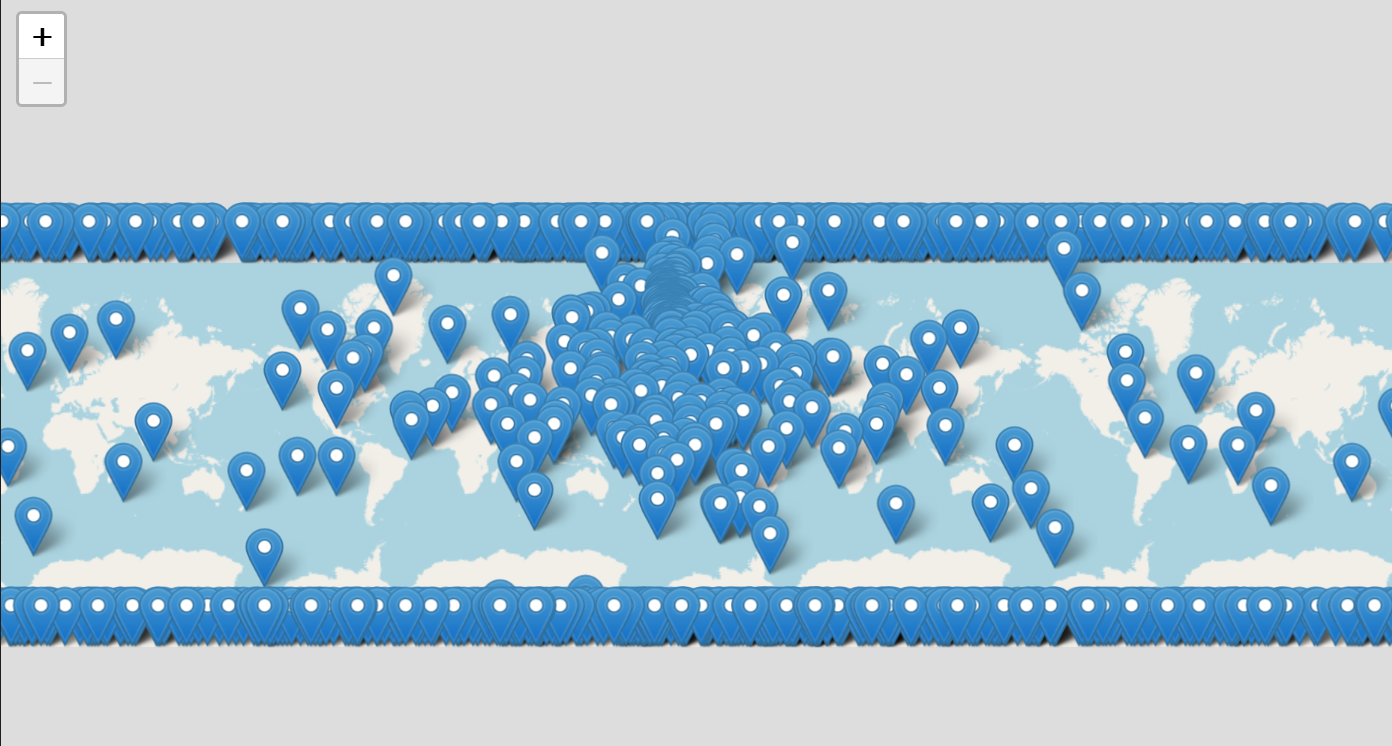

## 2. Filtrar zona y limpiar valores nulos o duplicados

In [24]:
df["mu_lon"] = df["mu_lon"].apply(lambda x: x-360 if x > 180 else x)

# Región válida: Beaufort y Chukchi
df = df[(df["mu_lat"] >= 65) & (df["mu_lat"] <= 80)]
df = df[(df["mu_lon"] >= -180) & (df["mu_lon"] <= -100)]

df = df.dropna(subset=["mu_lat", "mu_lon", "timestamp"])
df = df.drop_duplicates()

## 3. Ajuste de posición con Monte Carlo

In [25]:
def adjusted_position_mc(lat, lon, se_x, se_y, n=50):
    lat_std = se_y / 111000
    lon_std = se_x / (111000 * np.cos(np.radians(lat)) + 1e-6)
    lats = np.random.normal(lat, lat_std, n)
    lons = np.random.normal(lon, lon_std, n)
    return np.mean(lats), np.mean(lons)

df[["adj_lat", "adj_lon"]] = df.progress_apply(
    lambda row: adjusted_position_mc(row["mu_lat"], row["mu_lon"], row["se_mu_x"], row["se_mu_y"]),
    axis=1, result_type="expand"
)

100%|██████████| 295001/295001 [00:16<00:00, 17969.89it/s]


## 4. Calcular distancia, velocidad y aceleración

In [26]:
df["prev_lat"] = df.groupby("UniqueAnimalID")["adj_lat"].shift()
df["prev_lon"] = df.groupby("UniqueAnimalID")["adj_lon"].shift()
df["prev_time"] = df.groupby("UniqueAnimalID")["timestamp"].shift()

def calc_distance(row):
    if pd.notnull(row["prev_lat"]):
        return geodesic((row["adj_lat"], row["adj_lon"]), (row["prev_lat"], row["prev_lon"])).km
    return 0

df["distance_km"] = df.progress_apply(calc_distance, axis=1)
df["time_diff_hr"] = (df["timestamp"] - df["prev_time"]).dt.total_seconds() / 3600
df["velocity_kmh"] = df["distance_km"] / df["time_diff_hr"]

df["prev_velocity"] = df.groupby("UniqueAnimalID")["velocity_kmh"].shift()
df["acceleration_kmph2"] = (df["velocity_kmh"] - df["prev_velocity"]) / df["time_diff_hr"]

# Filtrar valores extremos
df = df[df["time_diff_hr"] >= 0.01]  # evitar divisiones raras

# Clip conservador en variables de movimiento
df["distance_km"] = df["distance_km"].clip(upper=150)
df["velocity_kmh"] = df["velocity_kmh"].clip(upper=20)
df["acceleration_kmph2"] = df["acceleration_kmph2"].clip(lower=-5, upper=5)


100%|██████████| 295001/295001 [00:46<00:00, 6326.12it/s]


## 5. Calcular horas de luz solar

In [27]:
eph = load('de421.bsp')
ts = load.timescale()

def get_daylight(lat, lon, date_str):
    d = datetime.strptime(date_str, '%Y-%m-%d').replace(tzinfo=timezone.utc)
    t0 = ts.utc(d.year, d.month, d.day)
    t1 = ts.utc((d + timedelta(days=1)).year, (d + timedelta(days=1)).month, (d + timedelta(days=1)).day)
    obs = Topos(latitude_degrees=lat, longitude_degrees=lon)
    f = sunrise_sunset(eph, obs)
    times, events = find_discrete(t0, t1, f)

    sunr, suns = None, None
    for ti, ev in zip(times, events):
        if ev == 1: sunr = ti.utc_datetime()
        elif ev == 0: suns = ti.utc_datetime()
    if sunr and suns:
        dh = max(0, min(24, abs((suns - sunr).total_seconds() / 3600)))
        return dh, False, False
    else:
        alt = eph['Earth'] + obs
        sun_alt = alt.at(t0).observe(eph['Sun']).apparent().altaz()[0].degrees
        if sun_alt > 0: return 24.0, False, True
        else: return 0.0, True, False

df["date"] = df["timestamp"].dt.date.astype(str)
df[["daylight_hours", "is_polar_night", "is_midnight_sun"]] = df.progress_apply(
    lambda row: get_daylight(row["adj_lat"], row["adj_lon"], row["date"]),
    axis=1, result_type="expand"
)

100%|██████████| 294608/294608 [2:08:58<00:00, 38.07it/s]  


In [31]:
df.head()

,UniqueAnimalID,timestamp,mu_lat,mu_lon,se_mu_x,se_mu_y,adj_lat,adj_lon,prev_lat,prev_lon,prev_time,distance_km,time_diff_hr,velocity_kmh,prev_velocity,acceleration_kmph2,date,daylight_hours,is_polar_night,is_midnight_sun
2,1,1986-07-01 12:00:00,69.7718,-141.3942,9375,9375,69.761663,-141.428310,69.769565,-141.323069,1986-07-01 06:00:00,4.158416,6.0,0.693069,NaN,NaN,1986-07-01,24.0,False,True
3,1,1986-07-01 18:00:00,69.7730,-141.3960,5835,5835,69.772693,-141.403451,69.761663,-141.428310,1986-07-01 12:00:00,1.560623,6.0,0.260104,0.693069,-0.072161,1986-07-01,24.0,False,True
4,1,1986-07-02 00:00:00,69.7738,-141.3834,2517,2517,69.773429,-141.388987,69.772693,-141.403451,1986-07-01 18:00:00,0.564330,6.0,0.094055,0.260104,-0.027675,1986-07-02,24.0,False,True
5,1,1986-07-02 06:00:00,69.7736,-141.3448,5323,5323,69.764930,-141.331186,69.773429,-141.388987,1986-07-02 00:00:00,2.424701,6.0,0.404117,0.094055,0.051677,1986-07-02,24.0,False,True
6,1,1986-07-02 12:00:00,69.7727,-141.2902,8840,8840,69.783728,-141.265125,69.764930,-141.331186,1986-07-02 06:00:00,3.301497,6.0,0.550249,0.404117,0.024355,1986-07-02,24.0,False,True


## 6. Guardar DS enriquecido

In [32]:
# GUARDAR DATASET PROCESADO
df.to_parquet("../data/processed/rich_dataset.parquet", index=False)


In [33]:
# GUARDAR DATASET PROCESADO
df.to_csv("../data/processed/rich_dataset.csv", index=False)


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 294608 entries, 2 to 338412
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   UniqueAnimalID      294608 non-null  int64         
 1   timestamp           294608 non-null  datetime64[ns]
 2   mu_lat              294608 non-null  float64       
 3   mu_lon              294608 non-null  float64       
 4   se_mu_x             294608 non-null  int64         
 5   se_mu_y             294608 non-null  int64         
 6   adj_lat             294608 non-null  float64       
 7   adj_lon             294608 non-null  float64       
 8   prev_lat            294608 non-null  float64       
 9   prev_lon            294608 non-null  float64       
 10  prev_time           294608 non-null  datetime64[ns]
 11  distance_km         294608 non-null  float64       
 12  time_diff_hr        294608 non-null  float64       
 13  velocity_kmh        294608 non-nul